In [ ]:
# 1. Import Required Libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
# 2. Dataset
text_data = [
    "machine learning is powerful",
    "machine learning is interesting",
    "deep learning is part of ai",
    "artificial intelligence is the future",
    "ai is transforming industries",
    "data science is important",
    "python is used for machine learning",
    "neural networks learn patterns",
    "big data helps in decision making",
    "ai improves automation in industries",
    "deep learning uses neural networks",
    "data analysis is important for business",
    "technology is growing rapidly",
    "computers solve complex problems",
    "algorithms are used in machine learning",
    "models are trained using data",
    "prediction is done using trained models",
    "ai applications are everywhere",
    "data scientists analyze large datasets",
    "programming is essential for ai"
]

In [ ]:
# 3. Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(text_data)
total_words = len(tokenizer.word_index) + 1



In [ ]:
# 4. Create Input Sequences
input_sequences = []

for line in text_data:
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)


In [ ]:
# 5. Padding Sequences
max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
)


In [ ]:
# 6. Split Data
X = input_sequences[:, :-1]
y = input_sequences[:, -1]


In [ ]:
# 7. Convert Output to Categorical
y = tf.keras.utils.to_categorical(y, num_classes=total_words)


In [ ]:
# 8. Build LSTM Model
model = Sequential()

model.add(Embedding(input_dim=total_words, output_dim=10, input_length=max_sequence_len-1))
model.add(LSTM(100))
model.add(Dense(total_words, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Fix for 0 params issue
model.build(input_shape=(None, max_sequence_len-1))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 10)          │           580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        44,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 58)             │         5,858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,838 (198.59 KB)

 Trainable params: 50,838 (198.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 9. Train the Model
print("Training the LSTM model...\n")
history = model.fit(X, y, epochs=100, verbose=1)

Training the LSTM model...

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0256 - loss: 4.0610
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1282 - loss: 4.0553
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1410 - loss: 4.0504
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1410 - loss: 4.0446
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1410 - loss: 4.0379
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1410 - loss: 4.0283
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1410 - loss: 4.0159
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1410 - loss: 3.9973
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1410 - loss: 3.9713
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1410 - loss: 3.9316
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1410 - loss: 3.8727
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/

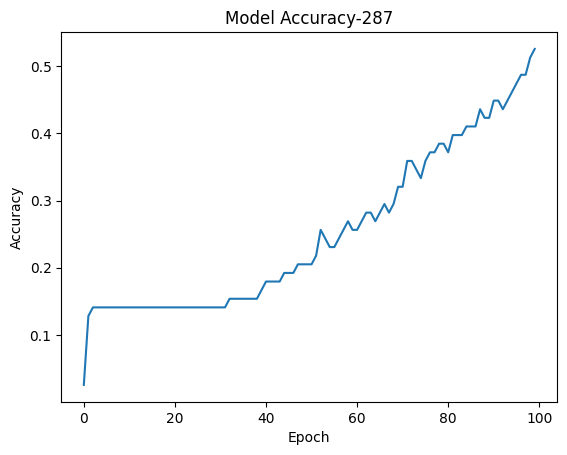

In [ ]:
# 10. Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.title("Model Accuracy-480")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()



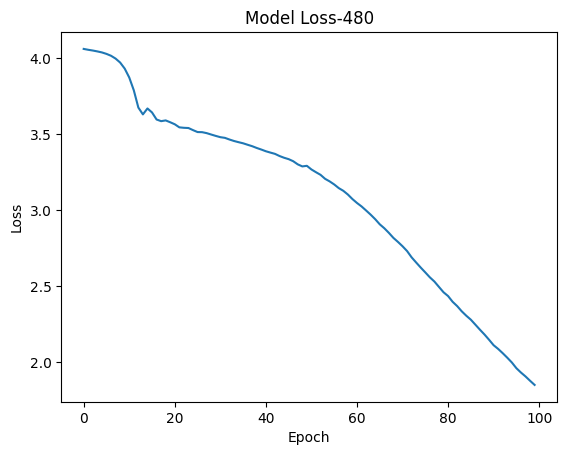

In [ ]:
# 11. Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.title("Model Loss-480")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [ ]:
# 12. Text Generation Function
def generate_text(seed_text, next_words):
    print("\nGenerating text...\n")

    for i in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word
        print("Generated word:", output_word)

    return seed_text

In [ ]:
# 13. Seed Text
seed = "machine learning"

In [ ]:
# 14. Generate Text
generated_text = generate_text(seed, 7)

print("\nFinal Generated Text:")
print(generated_text)



Generating text...

Generated word: is
Generated word: is
Generated word: important
Generated word: ai
Generated word: models
Generated word: models
Generated word: models

Final Generated Text:
machine learning is is important ai models models models
